Used Functions:

In [1]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt
import ot


# -------------------------
# Data generation
# -------------------------
def generate_uniform_grid(num_points_per_dim):
    x_linspace = np.linspace(0, 1, num_points_per_dim)
    y_linspace = np.linspace(0, 1, num_points_per_dim)
    X, Y = np.meshgrid(x_linspace, y_linspace)
    return np.column_stack([X.ravel(), Y.ravel()])


def neighbor_pairs(n):
    pairs = []
    for row in range(n):
        for col in range(n):
            idx = row * n + col

            if row + 1 < n:
                pairs.append((idx, (row + 1) * n + col))

            if col + 1 < n:
                pairs.append((idx, row * n + (col + 1)))

    return pairs


def simulate_uniform_distribution_in_ball(center, m, delta):
    r = delta * np.sqrt(np.random.rand(m))
    theta = 2 * np.pi * np.random.rand(m)

    return np.column_stack([
        center[0] + r * np.cos(theta),
        center[1] + r * np.sin(theta),
    ])


def f(xy):
    out = np.empty_like(xy)
    out[:, 0] = xy[:, 0] + xy[:, 1] ** 3
    out[:, 1] = xy[:, 1] - xy[:, 0] ** 3
    return out


def generate_centered_prototype_cloud(num_points_in_cloud, covariance_matrix):
    X0 = np.random.multivariate_normal(
        mean=np.zeros(covariance_matrix.shape[0]),
        cov=covariance_matrix,
        size=num_points_in_cloud,
    )
    return X0 - X0.mean(axis=0)


# -------------------------
# Distance computations
# -------------------------
def compute_transfer_matrix(u_samples, v_samples):
    N = u_samples.shape[0]

    a = np.ones(N) / N
    b = np.ones(N) / N

    M = ot.dist(u_samples, v_samples, metric="sqeuclidean")
    gamma = ot.emd(a, b, M)

    row_sums = gamma.sum(axis=1, keepdims=True)
    row_sums = np.maximum(row_sums, 1e-15)

    barycentric = (gamma @ v_samples) / row_sums
    return (barycentric - u_samples).ravel()


def sym_local_mahalanobis_sq(z_i, z_j, Sigma_i, Sigma_j, reg=1e-8):
    d = z_i - z_j
    I = np.eye(d.shape[0])

    Si = Sigma_i + reg * I
    Sj = Sigma_j + reg * I

    Si_inv = np.linalg.pinv(Si)
    Sj_inv = np.linalg.pinv(Sj)

    return 0.5 * d.T @ (Si_inv + Sj_inv) @ d

def compute_error_neighbors_only_mahalanobis(
    result,
    factor,
    pairs,
    fmean_dict,
    cov_f_dict,
):
    error_sum = 0.0

    for i, j in pairs:
        z_i = fmean_dict[i]
        z_j = fmean_dict[j]

        Sigma_i = cov_f_dict[i]
        Sigma_j = cov_f_dict[j]

        true_dm2 = sym_local_mahalanobis_sq(z_i, z_j, Sigma_i, Sigma_j)
        approx_distance = 0.5 * factor * result[(i, j)]

        error_sum += abs(true_dm2 - approx_distance)

    return error_sum / len(pairs)



def compute_ratio_and_order(values, scale_values):
    ratios = values[:-1] / values[1:]
    scale_ratios = scale_values[:-1] / scale_values[1:]
    observed_orders = np.log(ratios) / np.log(scale_ratios)

    return ratios, observed_orders



# -------------------------
# Table helper
# -------------------------
def make_table_rows(h_values, mean_values, std_values, ratios, observed_orders):
    rows = []

    for i in range(len(observed_orders)):
        rows.append([
            f"{h_values[i]:.5f}",
            f"{mean_values[i]:.5e}",
            f"{std_values[i]:.5e}",
            f"{ratios[i]:.5f}",
            f"{observed_orders[i]:.5f}",
        ])

    rows.append([
        f"{h_values[-1]:.5f}",
        f"{mean_values[-1]:.5e}",
        f"{std_values[-1]:.5e}",
        "",
        "",
    ])

    return rows

Experiment 1A:

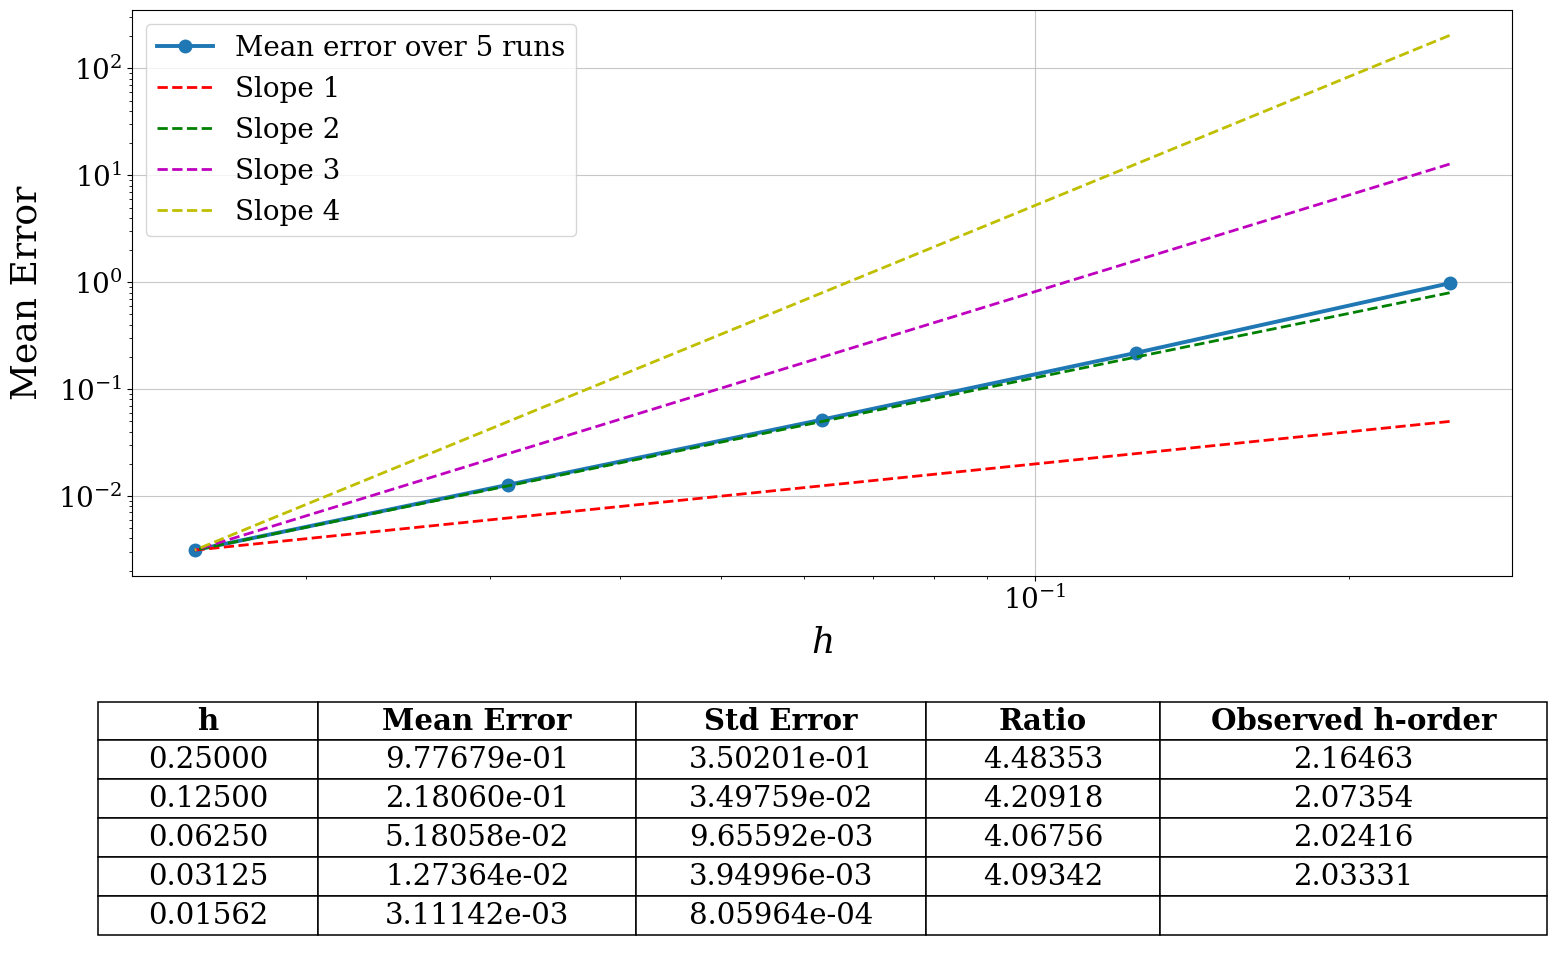

In [3]:

def distance_approximation(S1, num_points, delta, prototype_cloud, num_pairs=16):
    n = int(np.sqrt(S1.shape[0]))

    pairs = random.sample(neighbor_pairs(n), num_pairs)
    unique_indices = {i for i, j in pairs} | {j for i, j in pairs}

    point_clouds_transformed = {}
    point_clouds_base_transformed = {}
    fmean_dict = {}
    cov_f_dict = {}

    for idx in unique_indices:
        centers = simulate_uniform_distribution_in_ball(
            center=S1[idx],
            m=num_points,
            delta=delta,
        )

        base_cloud = S1[idx][None, :] + prototype_cloud
        base_cloud_f = f(base_cloud)

        point_clouds_base_transformed[idx] = base_cloud_f

        m_hat = base_cloud.mean(axis=0)
        fmean_dict[idx] = f(m_hat[None, :])[0]

        bursts = [
            centers[k][None, :] + prototype_cloud
            for k in range(num_points)
        ]
        point_clouds_transformed[idx] = [f(burst) for burst in bursts]

        f_centers = f(centers)
        cov_f_dict[idx] = np.cov(f_centers.T, bias=False)

    pseudo_inverses = {}

    for idx in unique_indices:
        u_samples = point_clouds_base_transformed[idx]

        vecs = [
            compute_transfer_matrix(u_samples, v_samples)
            for v_samples in point_clouds_transformed[idx]
        ]

        X = np.column_stack(vecs)
        A = (X @ X.T) / X.shape[1]

        U, s, Vt = np.linalg.svd(A, full_matrices=False)

        if s[0] <= 0:
            raise ValueError(f"Top singular value is nonpositive at idx={idx}")
        
        # Numerical tolerance for the truncated pseudo-inverse.
        # Singular values smaller than 1e-12 times the largest singular value
        # are treated as zero to avoid unstable inversion of near-zero values.

        tol = 1e-12 * s[0]
        s_inv = np.zeros_like(s)

        for k in range(min(2, len(s))):
            if s[k] > tol:
                s_inv[k] = 1.0 / s[k]

        pseudo_inverses[idx] = (Vt.T * s_inv) @ U.T

    result = {}

    for i, j in pairs:
        Ui = point_clouds_base_transformed[i]
        Uj = point_clouds_base_transformed[j]

        v_ij = compute_transfer_matrix(Ui, Uj)
        v_ji = compute_transfer_matrix(Uj, Ui)

        result[(i, j)] = (
            v_ij.T @ pseudo_inverses[i] @ v_ij
            + v_ji.T @ pseudo_inverses[j] @ v_ji
        )

    return result, pairs, fmean_dict, cov_f_dict



# -------------------------
# Plot + table figure
# -------------------------
def save_plot_and_table_figure(
    h_values,
    mean_values,
    y_label,
    curve_label,
    table_columns,
    table_rows,
    curve_color=None,
):
    plt.rcParams.update({
        "font.family": "DejaVu Serif",
        "mathtext.fontset": "dejavuserif",
        "font.size": 20,
        "axes.labelsize": 26,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 20,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    fig, (ax_plot, ax_tbl) = plt.subplots(
        2,
        1,
        figsize=(16, 10),
        gridspec_kw={"height_ratios": [3.4, 1.5]},
    )

    ax_plot.loglog(
        h_values,
        mean_values,
        "-o",
        color=curve_color,
        label=curve_label,
        linewidth=2.8,
        markersize=9,
    )

    ref_h = h_values[-1]
    ref_value = mean_values[-1]

    for slope, style, label in [
        (1, "r--", "Slope 1"),
        (2, "g--", "Slope 2"),
        (3, "m--", "Slope 3"),
        (4, "y--", "Slope 4"),
    ]:
        ref_line = ref_value * (h_values / ref_h) ** slope
        ax_plot.loglog(
            h_values,
            ref_line,
            style,
            label=label,
            linewidth=2.0,
        )

    ax_plot.set_xlabel(r"$h$", labelpad=8)
    ax_plot.set_ylabel(y_label, labelpad=10)
    ax_plot.legend(frameon=True)
    ax_plot.grid(True, which="major", linewidth=0.8, alpha=0.7)

    ax_tbl.axis("off")

    tbl = ax_tbl.table(
        cellText=table_rows,
        colLabels=table_columns,
        cellLoc="center",
        loc="center",
        colWidths=[0.16, 0.23, 0.21, 0.17, 0.28],
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(21)
    tbl.scale(1.0, 2.0)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_linewidth(1.1)
        cell.PAD = 0.08
        cell.set_text_props(ha="center", va="center")

        if row == 0:
            cell.set_text_props(weight="bold")

    fig.tight_layout(pad=1.2)
    plt.show()


# -------------------------
# Experiment runner
# -------------------------
def run_one_experiment(
    n_values,
    delta_list,
    cloud_std,
    cloud_size,
    num_points,
    factor_list,
):
    h_values = 1 / (n_values - 1)
    cov_h = (cloud_std ** 2) * np.eye(2)

    prototype_cloud = generate_centered_prototype_cloud(
        num_points_in_cloud=cloud_size,
        covariance_matrix=cov_h,
    )

    result_list = []
    pairs_list = []
    fmean_list = []
    covf_list = []

    for n, delta_i in zip(n_values, delta_list):
        S = generate_uniform_grid(n)

        result, pairs, fmean_dict, cov_f_dict = distance_approximation(
            S1=S,
            num_points=num_points,
            delta=delta_i,
            prototype_cloud=prototype_cloud,
        )

        result_list.append(result)
        pairs_list.append(pairs)
        fmean_list.append(fmean_dict)
        covf_list.append(cov_f_dict)

    errors = []

    for result, factor, pairs, fmean_dict, cov_f_dict in zip(
        result_list,
        factor_list,
        pairs_list,
        fmean_list,
        covf_list,
    ):
        err = compute_error_neighbors_only_mahalanobis(
            result=result,
            factor=factor,
            pairs=pairs,
            fmean_dict=fmean_dict,
            cov_f_dict=cov_f_dict,
        )
        errors.append(err)

    return np.array(errors), h_values


# -------------------------
# Run repeated experiment
# -------------------------
n_values = np.array([5, 9, 17, 33, 65])
delta_list = [0.05, 0.05, 0.05, 0.05, 0.05]

cloud_std = 0.01
cloud_size = 100 # corresponds to N_c in the paper/experiment setup
num_points = 100 # corresponds to M in the paper/experiment setup

factor_list = [1, 1, 1, 1, 1]
num_runs = 5

all_errors = []

for _ in range(num_runs):
    errors_run, h_values = run_one_experiment(
        n_values=n_values,
        delta_list=delta_list,
        cloud_std=cloud_std,
        cloud_size=cloud_size,
        num_points=num_points,
        factor_list=factor_list,
    )
    all_errors.append(errors_run)

all_errors = np.array(all_errors)

mean_errors = np.mean(all_errors, axis=0)
std_errors = np.std(all_errors, axis=0, ddof=1)

ratios, observed_orders = compute_ratio_and_order(mean_errors, h_values)


# -------------------------
# Combined table contents
# -------------------------
table_columns = [
    "h",
    "Mean Error",
    "Std Error",
    "Ratio",
    "Observed h-order",
]

table_rows = make_table_rows(
    h_values=h_values,
    mean_values=mean_errors,
    std_values=std_errors,
    ratios=ratios,
    observed_orders=observed_orders,
)


# -------------------------
# Output: combined plot + table
# -------------------------
save_plot_and_table_figure(
    h_values=h_values,
    mean_values=mean_errors,
    y_label="Mean Error",
    curve_label=f"Mean error over {num_runs} runs",
    table_columns=table_columns,
    table_rows=table_rows,
    curve_color=None,
)

Experiment 1B： 


Change num_points in Experiment 1A to 400, and 1600.

Experiment 2A

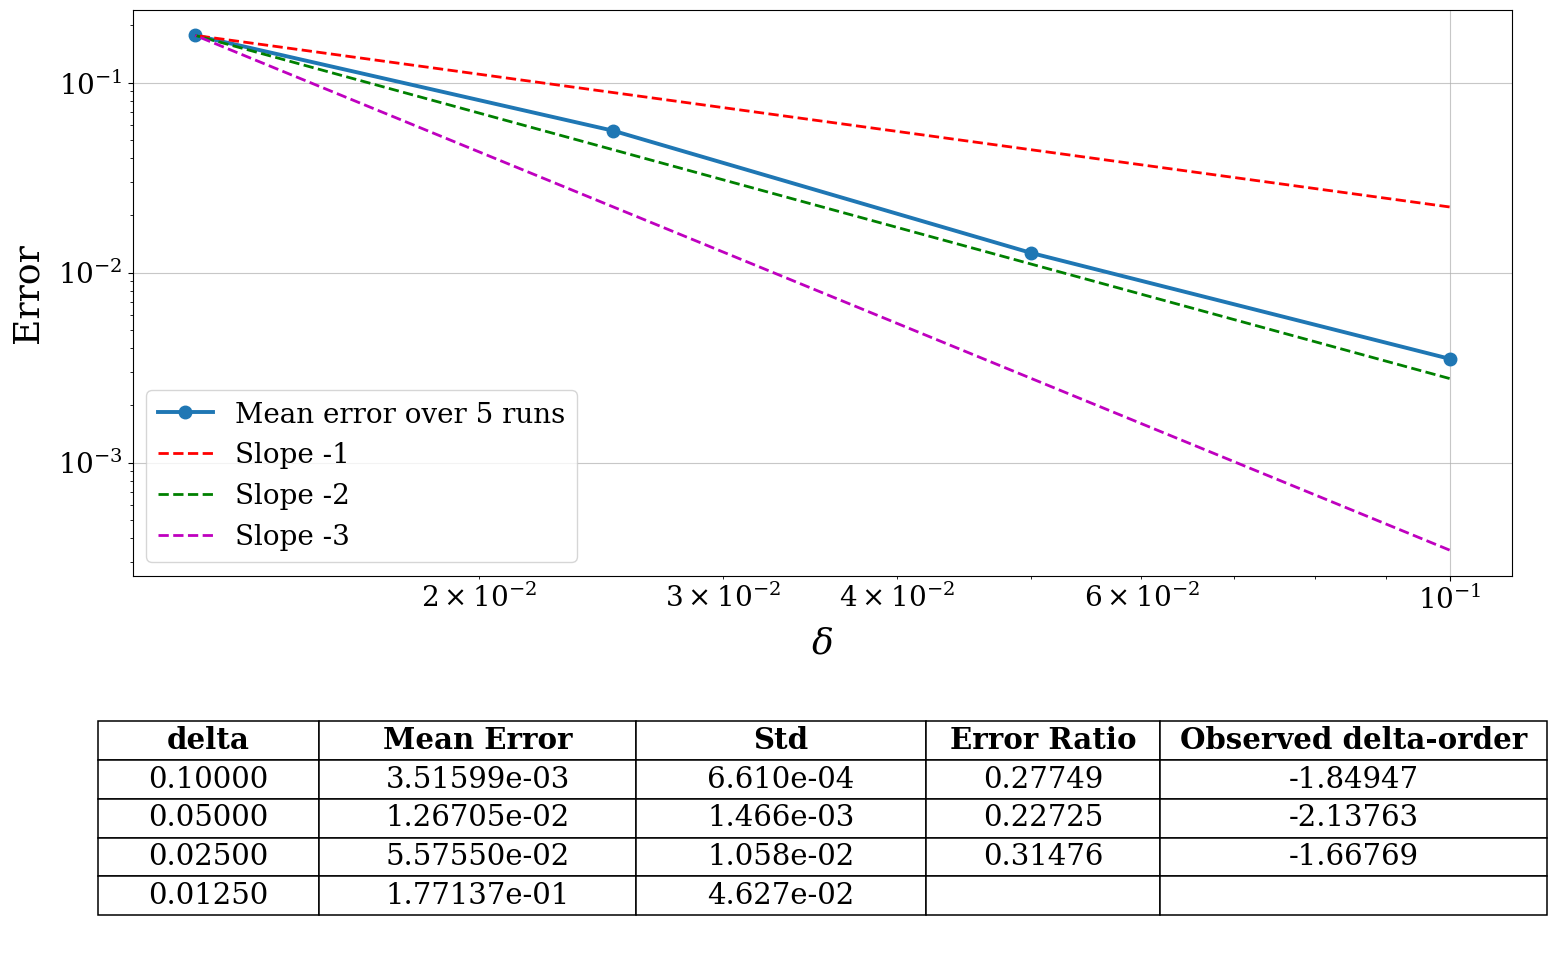

In [5]:
# -------------------------
# Delta-scaling distance approximation
# -------------------------
def distance_approximation_fixed_pairs(S1, num_points, delta, prototype_cloud, pairs):
    unique_indices = sorted({i for i, j in pairs} | {j for i, j in pairs})

    point_clouds_transformed = {}
    point_clouds_base_transformed = {}
    fmean_dict = {}
    cov_f_dict = {}
    pseudo_inverses = {}

    for idx in unique_indices:
        centers = simulate_uniform_distribution_in_ball(
            center=S1[idx],
            m=num_points,
            delta=delta,
        )

        base_cloud = S1[idx][None, :] + prototype_cloud
        base_cloud_f = f(base_cloud)

        point_clouds_base_transformed[idx] = base_cloud_f

        m_hat = base_cloud.mean(axis=0)
        fmean_dict[idx] = f(m_hat[None, :])[0]

        bursts = [
            centers[k][None, :] + prototype_cloud
            for k in range(num_points)
        ]
        point_clouds_transformed[idx] = [f(burst) for burst in bursts]

        f_centers = f(centers)
        cov_f_dict[idx] = np.cov(f_centers.T, bias=False)

    for idx in unique_indices:
        u_samples = point_clouds_base_transformed[idx]

        vecs = [
            compute_transfer_matrix(u_samples, v_samples)
            for v_samples in point_clouds_transformed[idx]
        ]

        X = np.column_stack(vecs)
        A = (X @ X.T) / X.shape[1]

        U, s, Vt = np.linalg.svd(A, full_matrices=False)

        if s[0] <= 0:
            raise ValueError(f"Top singular value is nonpositive at idx={idx}")

        # Numerical tolerance for the truncated pseudo-inverse.
        # Singular values smaller than 1e-10 times the largest singular value
        # are treated as zero to avoid unstable inversion of near-zero values.
        tol = 1e-10 * s[0]

        s_inv = np.zeros_like(s)

        # Since the local intrinsic dimension is 2, only invert the leading
        # two singular values. Very small singular values are ignored.
        for k in range(min(2, len(s))):
            if s[k] > tol:
                s_inv[k] = 1.0 / s[k]

        pseudo_inverses[idx] = (Vt.T * s_inv) @ U.T

    result = {}

    for i, j in pairs:
        Ui = point_clouds_base_transformed[i]
        Uj = point_clouds_base_transformed[j]

        v_ij = compute_transfer_matrix(Ui, Uj)
        v_ji = compute_transfer_matrix(Uj, Ui)

        result[(i, j)] = (
            v_ij.T @ pseudo_inverses[i] @ v_ij
            + v_ji.T @ pseudo_inverses[j] @ v_ji
        )

    return result, fmean_dict, cov_f_dict

# -------------------------
# Experiment runner
# -------------------------
def run_one_delta_trial(
    S,
    pairs_fixed,
    delta_list,
    prototype_cloud,
    num_points,
):
    result_list = []
    fmean_list = []
    covf_list = []

    for delta_i in delta_list:
        result, fmean_dict, cov_f_dict = distance_approximation_fixed_pairs(
            S1=S,
            num_points=num_points,
            delta=delta_i,
            prototype_cloud=prototype_cloud,
            pairs=pairs_fixed,
        )

        result_list.append(result)
        fmean_list.append(fmean_dict)
        covf_list.append(cov_f_dict)

    errors = []

    for result, fmean_dict, cov_f_dict in zip(
        result_list,
        fmean_list,
        covf_list,
    ):
        err = compute_error_neighbors_only_mahalanobis(
            result=result,
            factor=1,
            pairs=pairs_fixed,
            fmean_dict=fmean_dict,
            cov_f_dict=cov_f_dict,
        )
        errors.append(err)

    return np.array(errors)


# -------------------------
# Table helper
# -------------------------
def make_delta_table_rows(delta_list, errors_mean, errors_std, ratios, observed_orders):
    rows = []

    for i in range(len(observed_orders)):
        rows.append([
            f"{delta_list[i]:.5f}",
            f"{errors_mean[i]:.5e}",
            f"{errors_std[i]:.3e}",
            f"{ratios[i]:.5f}",
            f"{observed_orders[i]:.5f}",
        ])

    rows.append([
        f"{delta_list[-1]:.5f}",
        f"{errors_mean[-1]:.5e}",
        f"{errors_std[-1]:.3e}",
        "",
        "",
    ])

    return rows


# -------------------------
# Combined plot + table figure
# -------------------------
def show_delta_plot_and_table_figure(
    delta_list,
    errors_mean,
    table_columns,
    table_rows,
    curve_label,
):
    plt.rcParams.update({
        "font.family": "DejaVu Serif",
        "mathtext.fontset": "dejavuserif",
        "font.size": 20,
        "axes.labelsize": 26,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 20,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    fig, (ax_plot, ax_tbl) = plt.subplots(
        2,
        1,
        figsize=(16, 10),
        gridspec_kw={"height_ratios": [3.4, 1.5]},
    )

    ax_plot.loglog(
        delta_list,
        errors_mean,
        "-o",
        label=curve_label,
        linewidth=2.8,
        markersize=9,
    )

    ref_delta = delta_list[-1]
    ref_error = errors_mean[-1]

    for slope, style, label in [
        (-1, "r--", "Slope -1"),
        (-2, "g--", "Slope -2"),
        (-3, "m--", "Slope -3"),
    ]:
        error_line = ref_error * (delta_list / ref_delta) ** slope
        ax_plot.loglog(
            delta_list,
            error_line,
            style,
            label=label,
            linewidth=2.0,
        )

    ax_plot.set_xlabel(r"$\delta$", labelpad=8)
    ax_plot.set_ylabel("Error", labelpad=10)
    ax_plot.legend(frameon=True)
    ax_plot.grid(True, which="major", linewidth=0.8, alpha=0.7)

    ax_tbl.axis("off")

    tbl = ax_tbl.table(
        cellText=table_rows,
        colLabels=table_columns,
        cellLoc="center",
        loc="center",
        colWidths=[0.16, 0.23, 0.21, 0.17, 0.28],
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(21)
    tbl.scale(1.0, 2.0)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_linewidth(1.1)
        cell.PAD = 0.08
        cell.set_text_props(ha="center", va="center")

        if row == 0:
            cell.set_text_props(weight="bold")

    fig.tight_layout(pad=1.2)

    plt.show()


# -------------------------
# Main experiment
# -------------------------
n = 33
h = 1 / (n - 1)

S = generate_uniform_grid(n)

delta_list = np.array([0.1, 0.05, 0.025, 0.0125])

all_pairs = neighbor_pairs(n)
num_fixed_pairs = 16
pairs_fixed = random.sample(all_pairs, num_fixed_pairs)

cloud_std = 0.01
cloud_size = 100
cov_h = (cloud_std ** 2) * np.eye(2)

prototype_cloud = generate_centered_prototype_cloud(
    num_points_in_cloud=cloud_size,
    covariance_matrix=cov_h,
)

num_points = 100
num_trials = 5

all_errors = []

for _ in range(num_trials):
    errors_trial = run_one_delta_trial(
        S=S,
        pairs_fixed=pairs_fixed,
        delta_list=delta_list,
        prototype_cloud=prototype_cloud,
        num_points=num_points,
    )
    all_errors.append(errors_trial)

all_errors = np.array(all_errors)

errors_mean = all_errors.mean(axis=0)
errors_std = all_errors.std(axis=0)
ratios, observed_orders = compute_ratio_and_order(errors_mean, delta_list)


# -------------------------
# Combined table contents
# -------------------------
table_columns = [
    "delta",
    "Mean Error",
    "Std",
    "Error Ratio",
    "Observed delta-order",
]

table_rows = make_delta_table_rows(
    delta_list=delta_list,
    errors_mean=errors_mean,
    errors_std=errors_std,
    ratios=ratios,
    observed_orders=observed_orders,
)


# -------------------------
# output: combined plot + table
# -------------------------
show_delta_plot_and_table_figure(
    delta_list=delta_list,
    errors_mean=errors_mean,
    table_columns=table_columns,
    table_rows=table_rows,
    curve_label=f"Mean error over {num_trials} runs",
)

Experiment 2B:

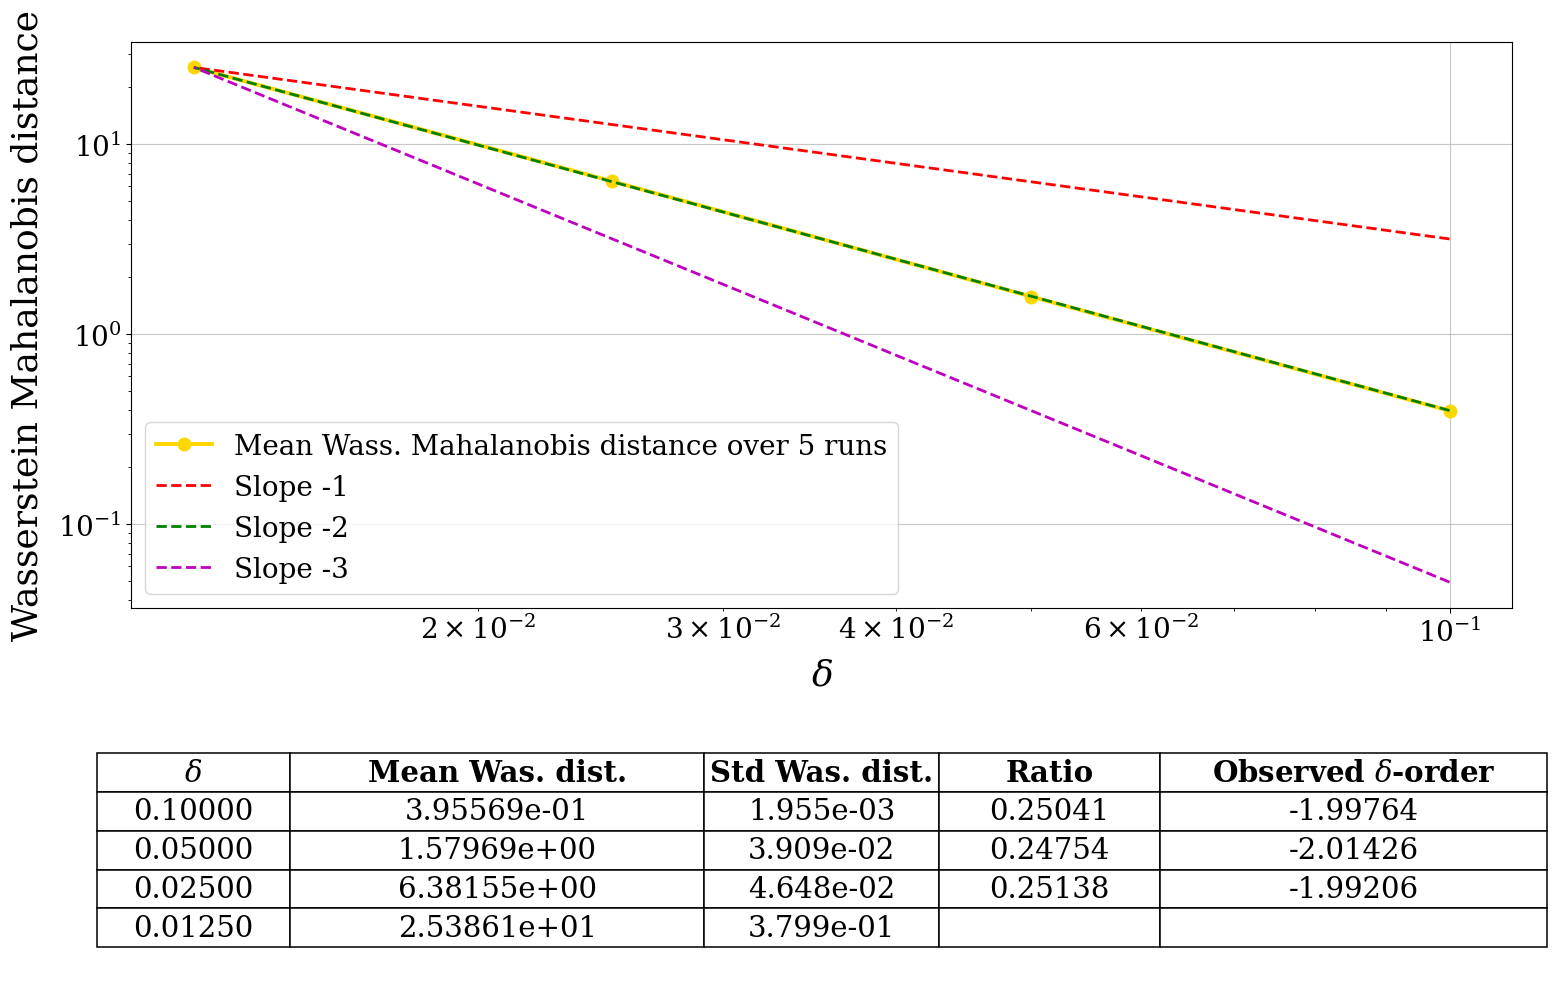

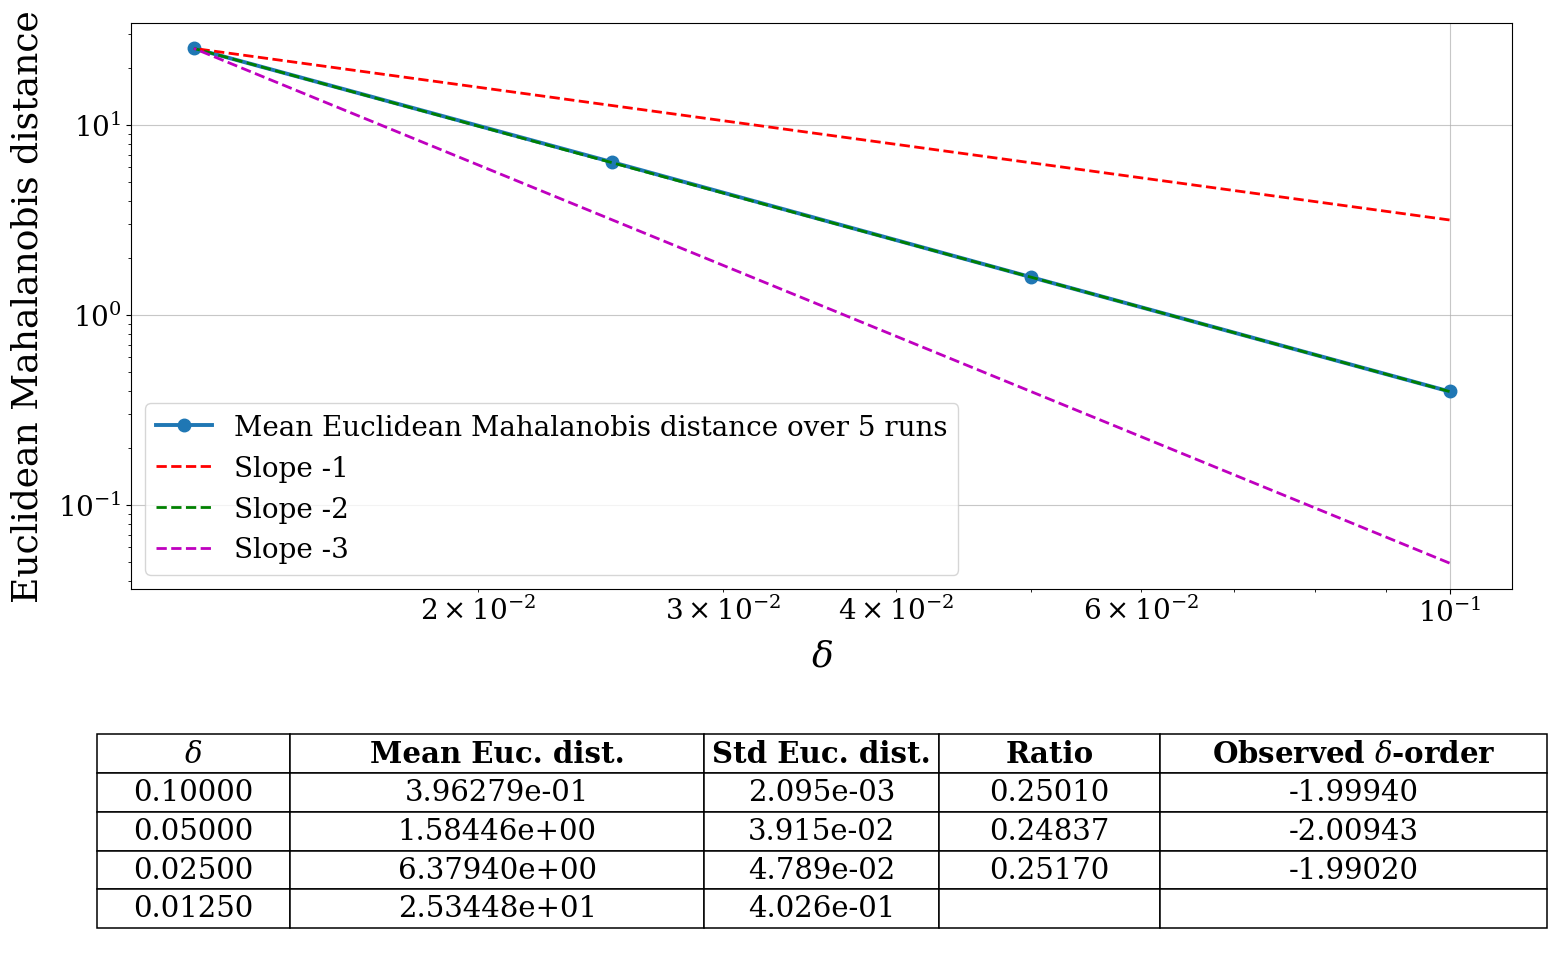

In [6]:
# -------------------------
# Delta-scaling distance approximation
# -------------------------
def distance_approximation_fixed_pairs(S1, num_points, delta, prototype_cloud, pairs):
    unique_indices = sorted({i for i, j in pairs} | {j for i, j in pairs})

    point_clouds_transformed = {}
    point_clouds_base_transformed = {}
    fmean_dict = {}
    cov_f_dict = {}
    pseudo_inverses = {}

    for idx in unique_indices:
        centers = simulate_uniform_distribution_in_ball(
            center=S1[idx],
            m=num_points,
            delta=delta,
        )

        base_cloud = S1[idx][None, :] + prototype_cloud
        base_cloud_f = f(base_cloud)

        point_clouds_base_transformed[idx] = base_cloud_f

        m_hat = base_cloud.mean(axis=0)
        fmean_dict[idx] = f(m_hat[None, :])[0]

        bursts = [
            centers[k][None, :] + prototype_cloud
            for k in range(num_points)
        ]
        point_clouds_transformed[idx] = [f(burst) for burst in bursts]

        f_centers = f(centers)
        cov_f_dict[idx] = np.cov(f_centers.T, bias=False)

    for idx in unique_indices:
        u_samples = point_clouds_base_transformed[idx]

        vecs = [
            compute_transfer_matrix(u_samples, v_samples)
            for v_samples in point_clouds_transformed[idx]
        ]

        X = np.column_stack(vecs)
        A = (X @ X.T) / X.shape[1]

        U, s, Vt = np.linalg.svd(A, full_matrices=False)

        if s[0] <= 0:
            raise ValueError(f"Top singular value is nonpositive at idx={idx}")

        # Numerical tolerance for the truncated pseudo-inverse.
        # Singular values smaller than 1e-10 times the largest singular value
        # are treated as zero to avoid unstable inversion of near-zero values.
        tol = 1e-10 * s[0]

        s_inv = np.zeros_like(s)

        # Since the local intrinsic dimension is 2, only invert the leading
        # two singular values. Very small singular values are ignored.
        for k in range(min(2, len(s))):
            if s[k] > tol:
                s_inv[k] = 1.0 / s[k]

        pseudo_inverses[idx] = (Vt.T * s_inv) @ U.T

    result = {}

    for i, j in pairs:
        Ui = point_clouds_base_transformed[i]
        Uj = point_clouds_base_transformed[j]

        v_ij = compute_transfer_matrix(Ui, Uj)
        v_ji = compute_transfer_matrix(Uj, Ui)

        result[(i, j)] = (
            v_ij.T @ pseudo_inverses[i] @ v_ij
            + v_ji.T @ pseudo_inverses[j] @ v_ji
        )

    return result, fmean_dict, cov_f_dict



# -------------------------
# Compute mean Wasserstein / Euclidean Mahalanobis distances
# -------------------------
def compute_distance_means(result, factor, pairs, fmean_dict, cov_f_dict):
    wasserstein_vals = []
    euclidean_vals = []

    for i, j in pairs:
        z_i = fmean_dict[i]
        z_j = fmean_dict[j]

        Sigma_i = cov_f_dict[i]
        Sigma_j = cov_f_dict[j]

        euclidean_dm = sym_local_mahalanobis_sq(
            z_i,
            z_j,
            Sigma_i,
            Sigma_j,
        )

        wasserstein_dm = 0.5 * factor * result[(i, j)]

        wasserstein_vals.append(wasserstein_dm)
        euclidean_vals.append(euclidean_dm)

    wasserstein_mean = np.mean(wasserstein_vals)
    euclidean_mean = np.mean(euclidean_vals)

    return wasserstein_mean, euclidean_mean


# -------------------------
# One trial for fixed h and varying delta
# -------------------------
def run_one_distance_trial(
    S,
    pairs_fixed,
    delta_list,
    prototype_cloud,
    num_points,
):
    wasserstein_means = []
    euclidean_means = []

    for delta_i in delta_list:
        result, fmean_dict, cov_f_dict = distance_approximation_fixed_pairs(
            S1=S,
            num_points=num_points,
            delta=delta_i,
            prototype_cloud=prototype_cloud,
            pairs=pairs_fixed,
        )

        wasserstein_mean, euclidean_mean = compute_distance_means(
            result=result,
            factor=1,
            pairs=pairs_fixed,
            fmean_dict=fmean_dict,
            cov_f_dict=cov_f_dict,
        )

        wasserstein_means.append(wasserstein_mean)
        euclidean_means.append(euclidean_mean)

    return np.array(wasserstein_means), np.array(euclidean_means)


# -------------------------
# Table helper
# -------------------------
def make_distance_table_rows(
    delta_list,
    mean_values,
    std_values,
    ratios,
    observed_orders,
):
    rows = []

    for i in range(len(observed_orders)):
        rows.append([
            f"{delta_list[i]:.5f}",
            f"{mean_values[i]:.5e}",
            f"{std_values[i]:.3e}",
            f"{ratios[i]:.5f}",
            f"{observed_orders[i]:.5f}",
        ])

    rows.append([
        f"{delta_list[-1]:.5f}",
        f"{mean_values[-1]:.5e}",
        f"{std_values[-1]:.3e}",
        "",
        "",
    ])

    return rows


# -------------------------
# Combined plot + table
# -------------------------
def show_distance_plot_and_table_figure(
    delta_list,
    values,
    y_label,
    curve_label,
    table_columns,
    table_rows,
    curve_color=None,
):
    plt.rcParams.update({
        "font.family": "DejaVu Serif",
        "mathtext.fontset": "dejavuserif",
        "font.size": 20,
        "axes.labelsize": 26,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 20,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    fig, (ax_plot, ax_tbl) = plt.subplots(
        2,
        1,
        figsize=(16, 10),
        gridspec_kw={"height_ratios": [3.4, 1.5]},
    )

    ax_plot.loglog(
        delta_list,
        values,
        "-o",
        color=curve_color,
        label=curve_label,
        linewidth=2.8,
        markersize=9,
    )

    ref_delta = delta_list[-1]
    ref_value = values[-1]

    for slope, style, label in [
        (-1, "r--", "Slope -1"),
        (-2, "g--", "Slope -2"),
        (-3, "m--", "Slope -3"),
    ]:
        ref_line = ref_value * (delta_list / ref_delta) ** slope
        ax_plot.loglog(
            delta_list,
            ref_line,
            style,
            label=label,
            linewidth=2.0,
        )

    ax_plot.set_xlabel(r"$\delta$", labelpad=8)
    ax_plot.set_ylabel(y_label, labelpad=10)
    ax_plot.legend(frameon=True)
    ax_plot.grid(True, which="major", linewidth=0.8, alpha=0.7)

    ax_tbl.axis("off")

    tbl = ax_tbl.table(
        cellText=table_rows,
        colLabels=table_columns,
        cellLoc="center",
        loc="center",
        colWidths=[0.14, 0.30, 0.17, 0.16, 0.28],
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(21)
    tbl.scale(1.0, 2.0)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_linewidth(1.1)
        cell.PAD = 0.08
        cell.set_text_props(ha="center", va="center")

        if row == 0:
            cell.set_text_props(weight="bold")

    fig.tight_layout(pad=1.2)

    plt.show()


# -------------------------
# Main experiment
# -------------------------

n = 33
S = generate_uniform_grid(n)

delta_list = np.array([0.1, 0.05, 0.025, 0.0125])

all_pairs = neighbor_pairs(n)
num_fixed_pairs = 16
pairs_fixed = random.sample(all_pairs, num_fixed_pairs)

cloud_std = 0.01
cloud_size = 100
cov_h = (cloud_std ** 2) * np.eye(2)

prototype_cloud = generate_centered_prototype_cloud(
    num_points_in_cloud=cloud_size,
    covariance_matrix=cov_h,
)

num_points = 100
num_trials = 5

all_wasserstein = []
all_euclidean = []

for _ in range(num_trials):
    wasserstein_trial, euclidean_trial = run_one_distance_trial(
        S=S,
        pairs_fixed=pairs_fixed,
        delta_list=delta_list,
        prototype_cloud=prototype_cloud,
        num_points=num_points,
    )

    all_wasserstein.append(wasserstein_trial)
    all_euclidean.append(euclidean_trial)

all_wasserstein = np.array(all_wasserstein)
all_euclidean = np.array(all_euclidean)


# -------------------------
# Mean and std over trials
# -------------------------
wasserstein_mean = all_wasserstein.mean(axis=0)
wasserstein_std = all_wasserstein.std(axis=0, ddof=1)

euclidean_mean = all_euclidean.mean(axis=0)
euclidean_std = all_euclidean.std(axis=0, ddof=1)


# -------------------------
# Ratios and observed orders
# -------------------------
wasserstein_ratios, wasserstein_orders = compute_ratio_and_order(
    wasserstein_mean,
    delta_list,
)

euclidean_ratios, euclidean_orders = compute_ratio_and_order(
    euclidean_mean,
    delta_list,
)


# -------------------------
# Wasserstein Mahalanobis table contents
# -------------------------
table_columns_w = [
    r"$\delta$",
    "Mean Was. dist.",
    "Std Was. dist.",
    "Ratio",
    r"Observed $\delta$-order",
]

table_rows_w = make_distance_table_rows(
    delta_list=delta_list,
    mean_values=wasserstein_mean,
    std_values=wasserstein_std,
    ratios=wasserstein_ratios,
    observed_orders=wasserstein_orders,
)


# -------------------------
# Euclidean Mahalanobis table contents
# -------------------------
table_columns_e = [
    r"$\delta$",
    "Mean Euc. dist.",
    "Std Euc. dist.",
    "Ratio",
    r"Observed $\delta$-order",
]

table_rows_e = make_distance_table_rows(
    delta_list=delta_list,
    mean_values=euclidean_mean,
    std_values=euclidean_std,
    ratios=euclidean_ratios,
    observed_orders=euclidean_orders,
)


# -------------------------
# Output 1: Wasserstein Mahalanobis combined figure
# -------------------------
show_distance_plot_and_table_figure(
    delta_list=delta_list,
    values=wasserstein_mean,
    y_label="Wasserstein Mahalanobis distance",
    curve_label=f"Mean Wass. Mahalanobis distance over {num_trials} runs",
    table_columns=table_columns_w,
    table_rows=table_rows_w,
    curve_color="gold",
)


# -------------------------
# Output 2: Euclidean Mahalanobis combined figure
# -------------------------
show_distance_plot_and_table_figure(
    delta_list=delta_list,
    values=euclidean_mean,
    y_label="Euclidean Mahalanobis distance",
    curve_label=f"Mean Euclidean Mahalanobis distance over {num_trials} runs",
    table_columns=table_columns_e,
    table_rows=table_rows_e,
    curve_color=None,
)

Experiment 3A:

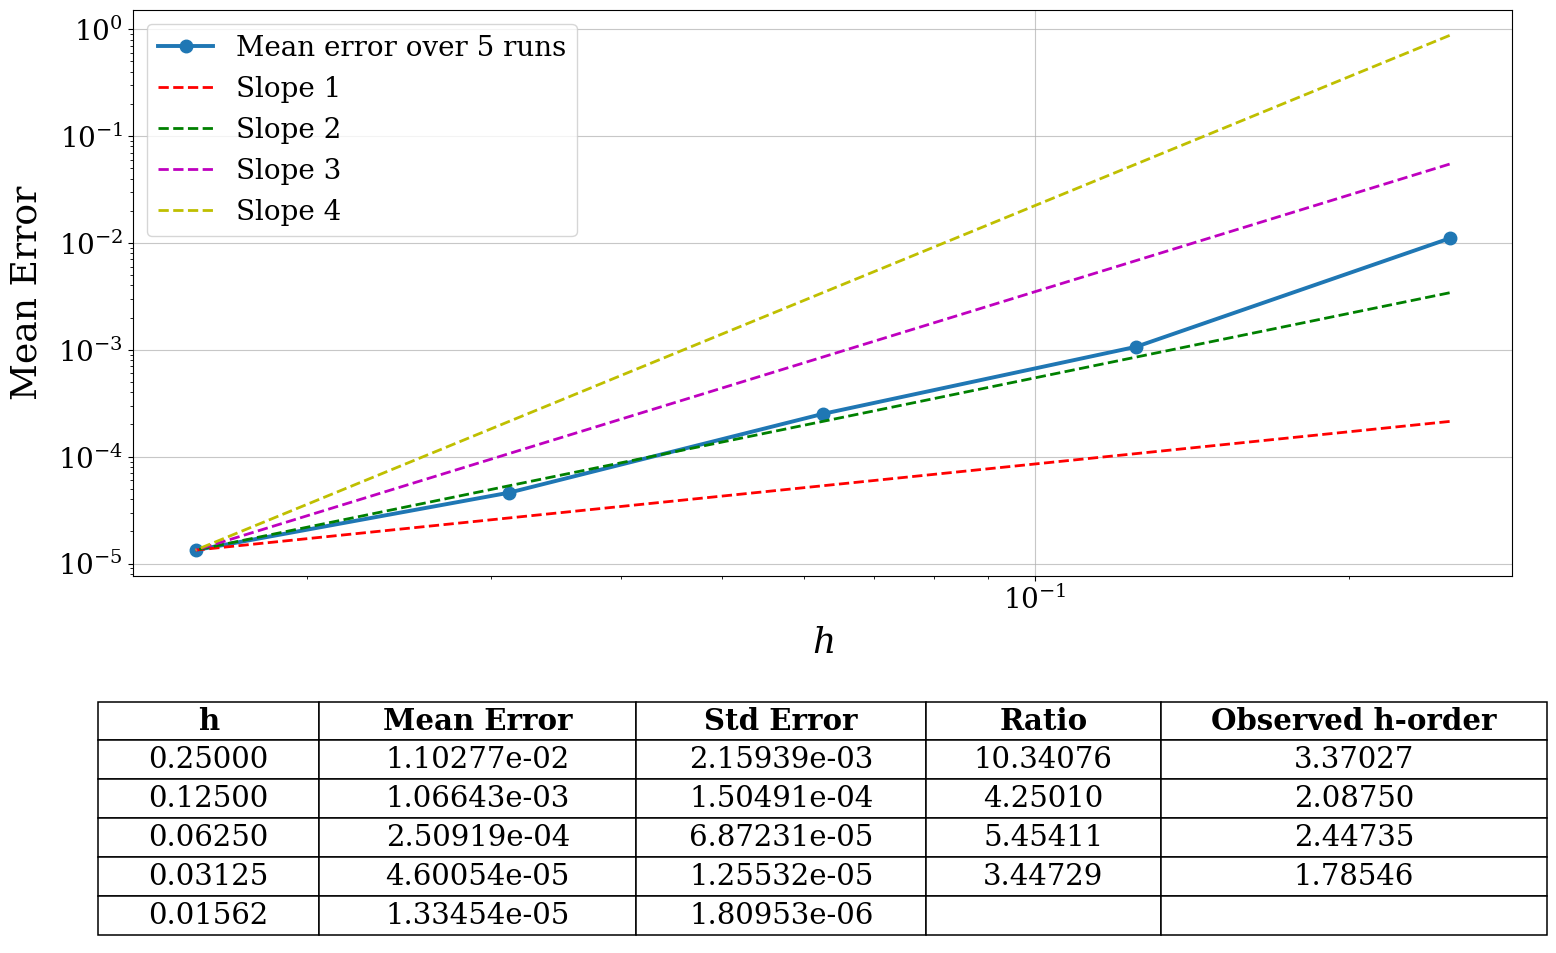

In [2]:
# -------------------------
# Distance approximation for Euclidean-before-f error
# -------------------------
def distance_approximation_euclidean_before_f(
    S1,
    num_points,
    delta,
    prototype_cloud,
    num_pairs=16,
):
    n = int(np.sqrt(S1.shape[0]))

    pairs = random.sample(neighbor_pairs(n), num_pairs)
    unique_indices = {i for i, j in pairs} | {j for i, j in pairs}

    point_clouds_transformed = {}
    point_clouds_base_transformed = {}
    mean_dict = {}

    for idx in unique_indices:
        # Original grid mean before applying f.
        mean_dict[idx] = S1[idx]

        centers = simulate_uniform_distribution_in_ball(
            center=S1[idx],
            m=num_points,
            delta=delta,
        )

        base_cloud = S1[idx][None, :] + prototype_cloud
        point_clouds_base_transformed[idx] = f(base_cloud)

        bursts = [
            centers[k][None, :] + prototype_cloud
            for k in range(num_points)
        ]
        point_clouds_transformed[idx] = [f(burst) for burst in bursts]

    pseudo_inverses = {}

    for idx in unique_indices:
        u_samples = point_clouds_base_transformed[idx]

        vecs = [
            compute_transfer_matrix(u_samples, v_samples)
            for v_samples in point_clouds_transformed[idx]
        ]

        X = np.column_stack(vecs)
        A = (X @ X.T) / X.shape[1]

        U, s, Vt = np.linalg.svd(A, full_matrices=False)

        if s[0] <= 0:
            raise ValueError(f"Top singular value is nonpositive at idx={idx}")

        # Numerical tolerance for the truncated pseudo-inverse.
        # Singular values smaller than 1e-12 times the largest singular value
        # are treated as zero to avoid unstable inversion of near-zero values.
        tol = 1e-12 * s[0]

        s_inv = np.zeros_like(s)

        # Since the original space is 2D, only invert the leading
        # two singular values. Very small singular values are ignored.
        for k in range(min(2, len(s))):
            if s[k] > tol:
                s_inv[k] = 1.0 / s[k]

        pseudo_inverses[idx] = (Vt.T * s_inv) @ U.T

    result = {}

    for i, j in pairs:
        Ui = point_clouds_base_transformed[i]
        Uj = point_clouds_base_transformed[j]

        v_ij = compute_transfer_matrix(Ui, Uj)
        v_ji = compute_transfer_matrix(Uj, Ui)

        result[(i, j)] = (
            v_ij.T @ pseudo_inverses[i] @ v_ij
            + v_ji.T @ pseudo_inverses[j] @ v_ji
        )

    return result, pairs, mean_dict


# -------------------------
# Error against Euclidean distance before f
# -------------------------
def compute_error_neighbors_only_euclidean_before_f(
    result,
    delta,
    pairs,
    mean_dict,
):
    error_sum = 0.0
    factor = delta ** 2 / 4

    for i, j in pairs:
        m_i = mean_dict[i]
        m_j = mean_dict[j]

        true_dist2 = np.sum((m_i - m_j) ** 2)
        approx_distance = 0.5 * factor * result[(i, j)]

        error_sum += abs(true_dist2 - approx_distance)

    return error_sum / len(pairs)


# -------------------------
# experiment runner
# -------------------------
def run_one_euclidean_before_f_experiment(
    n_values,
    delta_list,
    cloud_std,
    cloud_size,
    num_points,
):
    h_values = 1 / (n_values - 1)
    cov_h = (cloud_std ** 2) * np.eye(2)

    prototype_cloud = generate_centered_prototype_cloud(
        num_points_in_cloud=cloud_size,
        covariance_matrix=cov_h,
    )

    result_list = []
    pairs_list = []
    mean_list = []

    for n, delta_i in zip(n_values, delta_list):
        S = generate_uniform_grid(n)

        result, pairs, mean_dict = distance_approximation_euclidean_before_f(
            S1=S,
            num_points=num_points,
            delta=delta_i,
            prototype_cloud=prototype_cloud,
        )

        result_list.append(result)
        pairs_list.append(pairs)
        mean_list.append(mean_dict)

    errors = []

    for result, delta_i, pairs, mean_dict in zip(
        result_list,
        delta_list,
        pairs_list,
        mean_list,
    ):
        err = compute_error_neighbors_only_euclidean_before_f(
            result=result,
            delta=delta_i,
            pairs=pairs,
            mean_dict=mean_dict,
        )
        errors.append(err)

    return np.array(errors), h_values


# -------------------------
# Combined plot + table figure
# -------------------------
def show_h_error_plot_and_table_figure(
    h_values,
    mean_values,
    y_label,
    curve_label,
    table_columns,
    table_rows,
    curve_color=None,
):
    plt.rcParams.update({
        "font.family": "DejaVu Serif",
        "mathtext.fontset": "dejavuserif",
        "font.size": 20,
        "axes.labelsize": 26,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 20,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    fig, (ax_plot, ax_tbl) = plt.subplots(
        2,
        1,
        figsize=(16, 10),
        gridspec_kw={"height_ratios": [3.4, 1.5]},
    )

    ax_plot.loglog(
        h_values,
        mean_values,
        "-o",
        color=curve_color,
        label=curve_label,
        linewidth=2.8,
        markersize=9,
    )

    ref_h = h_values[-1]
    ref_value = mean_values[-1]

    for slope, style, label in [
        (1, "r--", "Slope 1"),
        (2, "g--", "Slope 2"),
        (3, "m--", "Slope 3"),
        (4, "y--", "Slope 4"),
    ]:
        ref_line = ref_value * (h_values / ref_h) ** slope
        ax_plot.loglog(
            h_values,
            ref_line,
            style,
            label=label,
            linewidth=2.0,
        )

    ax_plot.set_xlabel(r"$h$", labelpad=8)
    ax_plot.set_ylabel(y_label, labelpad=10)
    ax_plot.legend(frameon=True)
    ax_plot.grid(True, which="major", linewidth=0.8, alpha=0.7)

    ax_tbl.axis("off")

    tbl = ax_tbl.table(
        cellText=table_rows,
        colLabels=table_columns,
        cellLoc="center",
        loc="center",
        colWidths=[0.16, 0.23, 0.21, 0.17, 0.28],
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(21)
    tbl.scale(1.0, 2.0)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_linewidth(1.1)
        cell.PAD = 0.08
        cell.set_text_props(ha="center", va="center")

        if row == 0:
            cell.set_text_props(weight="bold")

    fig.tight_layout(pad=1.2)

    plt.show()


# -------------------------
# Run repeated experiment
# -------------------------
n_values = np.array([5, 9, 17, 33, 65])
delta_list = [0.05, 0.05, 0.05, 0.05, 0.05]

cloud_std = 0.01
cloud_size = 100 # corresponds to N_c in the paper/experiment setup
num_points = 100 # corresponds to M in the paper/experiment setup

num_runs = 5

all_errors = []

for _ in range(num_runs):
    errors_run, h_values = run_one_euclidean_before_f_experiment(
        n_values=n_values,
        delta_list=delta_list,
        cloud_std=cloud_std,
        cloud_size=cloud_size,
        num_points=num_points,
    )
    all_errors.append(errors_run)

all_errors = np.array(all_errors)

mean_errors = np.mean(all_errors, axis=0)

if num_runs > 1:
    std_errors = np.std(all_errors, axis=0, ddof=1)
else:
    std_errors = np.zeros_like(mean_errors)

ratios, observed_orders = compute_ratio_and_order(mean_errors, h_values)


# -------------------------
# Combined table contents
# -------------------------
table_columns = [
    "h",
    "Mean Error",
    "Std Error",
    "Ratio",
    "Observed h-order",
]

table_rows = make_table_rows(
    h_values=h_values,
    mean_values=mean_errors,
    std_values=std_errors,
    ratios=ratios,
    observed_orders=observed_orders,
)


# -------------------------
# Only output: combined plot + table figure
# -------------------------
show_h_error_plot_and_table_figure(
    h_values=h_values,
    mean_values=mean_errors,
    y_label="Mean Error",
    curve_label=f"Mean error over {num_runs} runs",
    table_columns=table_columns,
    table_rows=table_rows,
    curve_color=None,
)

Experiment 3B:

Change the setting in Experiment 3A to the following:

delta_list = [0.00000001, 0.00000001, 0.00000001, 0.00000001, 0.00000001]

cloud_std = 0.000000000000000000000000000000000000000000000000000000000000000000000000001
cloud_size = 1
num_points = 320000

and

delta_list = [0.3, 0.3, 0.3, 0.3, 0.3]

cloud_std = 0.000000000000000000000000000000000000000000000000000000000000000000000000001
cloud_size = 1
num_points = 320000